# Stock Trading Strategy Comparison: Buy and Hold vs. SMA Crossover

## Project Introduction
This project aims to compare two fundamental investment strategies: a passive 'Buy and Hold' approach and an active 'Simple Moving Average (SMA) Crossover' strategy. Using historical stock data for Apple (AAPL), we will simulate both strategies over a 30-year period to evaluate their performance based on final portfolio value and annualized returns. Why Apple? well we need a blue chip stock with enough history to backtest the strategies. The results can be generalized to most stocks that also have significant volumes of historical data. This analysis provides insights into the potential benefits and drawbacks of passive vs. active trading, highlighting the role of technical indicators in decision-making.

## Theory Involved

### Buy and Hold Strategy
This is a passive investment strategy where an investor buys a stock and holds it for a long period, regardless of fluctuations in the market. The core belief is that, over the long term, equity markets tend to provide positive returns, and trying to 'time the market' is often unprofitable due to transaction costs and the difficulty of consistent prediction.

### Simple Moving Average (SMA) Crossover Strategy
This is a common technical analysis strategy. An SMA is the average of a stock's closing prices over a specified period. The SMA crossover strategy typically uses two SMAs: a short-term SMA (e.g., 50 days) and a long-term SMA (e.g., 200 days).
*   **Buy Signal**: Generated when the short-term SMA crosses above the long-term SMA. This suggests an upward momentum (bullish signal).
*   **Sell Signal**: Generated when the short-term SMA crosses below the long-term SMA. This suggests a downward momentum (bearish signal).

### Machine Learning Practices
While this project doesn't employ complex machine learning models, it utilizes fundamental data science practices:
*   **Data Collection**: Fetching historical stock data from a reliable source (Yahoo Finance).
*   **Data Preprocessing**: Cleaning and preparing the data for analysis, including handling time series indices and calculating technical indicators.
*   **Feature Engineering**: Creating new features like SMAs from raw closing prices.
*   **Strategy Simulation**: Implementing algorithmic trading logic based on defined rules.
*   **Performance Evaluation**: Quantifying the outcomes of different strategies using metrics like final value and annual return.
*   **Visualization**: Using plots to effectively communicate trends and comparative performance.

## Goal
The primary goal is to demonstrate the process of fetching historical stock data, applying technical analysis indicators, simulating trading strategies, and comparing their performance. This project serves as a foundational example for understanding quantitative finance concepts and can be extended with more advanced machine learning models for predictive analysis.

## Data Collection and Initial Overview
This cell uses the `yfinance` library to fetch 30 years of historical stock data for Apple (`AAPL`). It then prints the first few rows, last few rows, and a statistical summary of the dataset to provide an initial understanding of the data structure and content.

In [1]:
import yfinance as yf
import pandas as pd

# Fetching 30 years of historical data for AAPL
ticker = "AAPL"
data = yf.Ticker(ticker).history(period="30y")

print("First few rows of the data:")
print(data.head())

print("\nLast few rows of the data:")
print(data.tail())

print("\nSummary of the data:")
print(data.describe())

First few rows of the data:
                               Open      High       Low     Close     Volume  \
Date                                                                           
1996-04-17 00:00:00-04:00  0.193823  0.194760  0.188205  0.189141   85411200   
1996-04-18 00:00:00-04:00  0.190078  0.190195  0.181651  0.185396  217246400   
1996-04-19 00:00:00-04:00  0.184460  0.188205  0.184460  0.187737  101796800   
1996-04-22 00:00:00-04:00  0.189141  0.191015  0.186332  0.188205  111115200   
1996-04-23 00:00:00-04:00  0.188205  0.189141  0.184460  0.185396  169948800   

                           Dividends  Stock Splits  
Date                                                
1996-04-17 00:00:00-04:00        0.0           0.0  
1996-04-18 00:00:00-04:00        0.0           0.0  
1996-04-19 00:00:00-04:00        0.0           0.0  
1996-04-22 00:00:00-04:00        0.0           0.0  
1996-04-23 00:00:00-04:00        0.0           0.0  

Last few rows of the data:
            

## Visualize Closing Price Trend
This cell plots the historical closing prices of Apple stock over the 30-year period. This visualization helps in understanding the long-term price trend and overall market behavior.

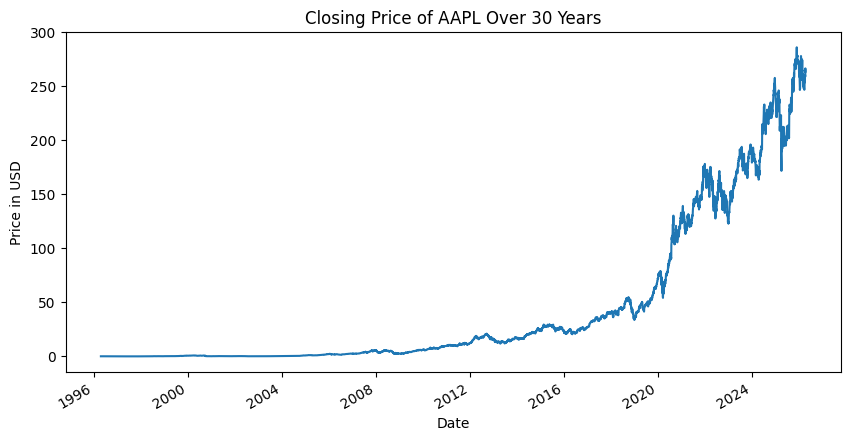

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
data['Close'].plot(title=f'Closing Price of {ticker} Over 30 Years')
plt.ylabel('Price in USD')
plt.show()

## Prepare for TA-Lib Installation (Change Directory)
This cell changes the current working directory to `/usr`. This is a necessary step for installing `TA-Lib`, a technical analysis library, as it requires specific directory access for its compilation and installation process.

In [3]:
import os
os.chdir("/usr")

## Download and Extract TA-Lib Source
This cell downloads the `TA-Lib` source code from SourceForge and extracts it. `TA-Lib` is a widely used library for technical analysis indicators, which will be essential for calculating SMAs.

In [4]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz -P /usr
!tar -xzf ta-lib-0.4.0-src.tar.gz

--2026-04-17 06:03:57--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:d95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.12.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2026-04-17 06:03:57--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:d95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://cytranet-dal.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2026-04-17 06:03:57--  http://cytranet-dal

## Navigate to TA-Lib Source Directory
After extracting, this cell changes the current working directory into the newly created `ta-lib` source directory, preparing for the compilation steps.

In [5]:
import os
os.chdir('/usr/ta-lib')

## Compile and Install TA-Lib
These commands configure, compile, and install the `TA-Lib` library from its source code. This process makes the library available on the system so that its Python wrapper can be installed and used.

In [6]:
!./configure --prefix=/usr
!make
!sudo make install

checking for a BSD-compatible install... /usr/bin/install -c
checking whether build environment is sane... yes
checking for a thread-safe mkdir -p... /usr/bin/mkdir -p
checking for gawk... no
checking for mawk... mawk
checking whether make sets $(MAKE)... yes
checking for gcc... gcc
checking for C compiler default output file name... a.out
checking whether the C compiler works... yes
checking whether we are cross compiling... no
checking for suffix of executables... 
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether gcc accepts -g... yes
checking for gcc option to accept ISO C89... none needed
checking for style of include used by make... GNU
checking dependency style of gcc... gcc3
checking build system type... x86_64-unknown-linux-gnu
checking host system type... x86_64-unknown-linux-gnu
checking for a sed that does not truncate output... /usr/bin/sed
checking for grep that handles long lines and -e... /usr/bin/grep
chec

## Install TA-Lib Python Wrapper
This cell installs the Python wrapper for `TA-Lib` using `pip`. Once installed, we can import `talib` and use its functions to calculate various technical indicators directly within Python.

In [7]:
!pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 38.4 MB/s eta 0:00:00


## Calculate Simple Moving Averages (SMAs) and Generate Signals
This cell calculates the 50-day (short-term) and 200-day (long-term) Simple Moving Averages (SMAs) for the closing prices. It then generates a trading 'Signal': 1 when the short-term SMA crosses above the long-term SMA (buy signal), and 0 otherwise. The signal is shifted to represent the action to be taken on the *next* day.

In [8]:
import talib as ta

# Calculate the Simple Moving Average (SMA) Crossover
sma_short_period = 50  # Short-term SMA
sma_long_period = 200  # Long-term SMA

data['SMA_short'] = ta.SMA(data['Close'], timeperiod=sma_short_period)
data['SMA_long'] = ta.SMA(data['Close'], timeperiod=sma_long_period)
data['Signal'] = 0  # Default no signal
data['Signal'][sma_long_period:] = (data['SMA_short'][sma_long_period:] > data['SMA_long'][sma_long_period:]).astype(int)
data['Signal'] = data['Signal'].shift()  # Shifting signal for next day's action

/tmp/ipykernel_12190/3523561013.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Signal'][sma_long_period:] = (data['SMA_short'][sma_long_period:] > data['SMA_long'][sma_long_period:]).astype(int)
/tmp/ipykernel_12190/3523561013.py

## Plot SMAs with Closing Price
This cell visualizes the stock's closing price along with the calculated short-term and long-term SMAs. This plot helps to visually identify the trends and potential crossover points that form the basis of the active trading strategy.

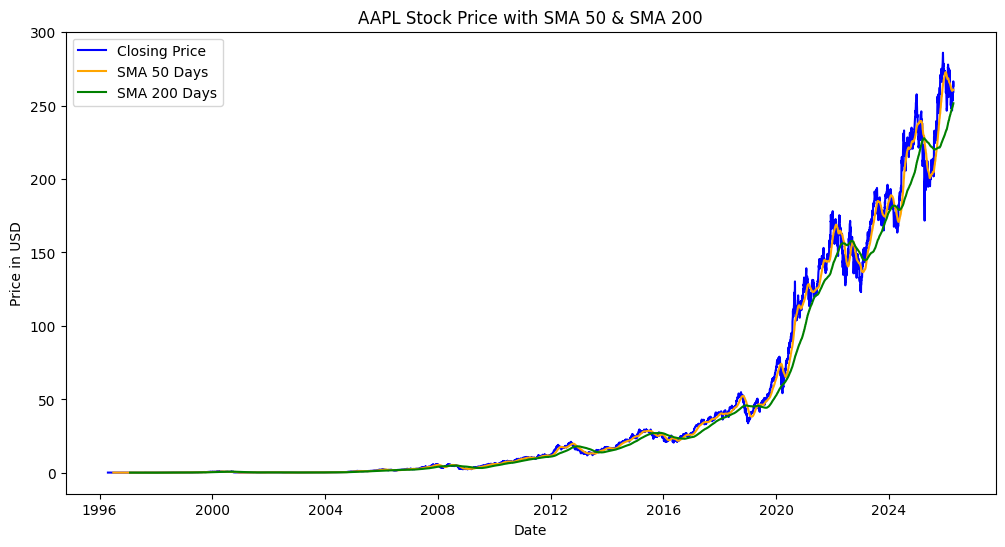

In [9]:
# Plot the Closing Price, Short-term SMA, and Long-term SMA
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Closing Price', color='blue')
plt.plot(data.index, data['SMA_short'], label=f'SMA {sma_short_period} Days', color='orange')
plt.plot(data.index, data['SMA_long'], label=f'SMA {sma_long_period} Days', color='green')

# Adding title and labels
plt.title(f'{ticker} Stock Price with SMA {sma_short_period} & SMA {sma_long_period}')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Show the plot
plt.show()

## Identify and Plot SMA Crossover Signals
This cell refines the visualization by explicitly marking the buy and sell signals on the chart. Upward triangles indicate buy signals (short SMA crosses above long SMA), and downward triangles indicate sell signals (short SMA crosses below long SMA). This provides a clear graphical representation of the strategy's entry and exit points.

/tmp/ipykernel_12190/2833067976.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  crossovers['signal'][sma_short_period:] = np.where(crossovers['short_sma'][sma_short_period:] > crossovers['long_sma'][sma_short_period:], 1.0, 0.0)


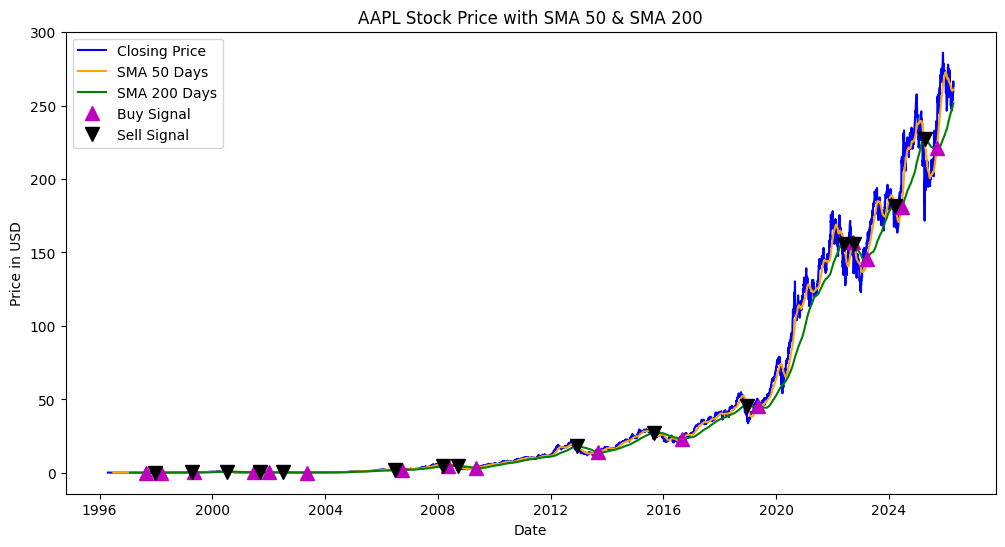

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Identifying the crossover points
crossovers = pd.DataFrame(index=data.index)
crossovers['price'] = data['Close']
crossovers['short_sma'] = data['SMA_short']
crossovers['long_sma'] = data['SMA_long']
crossovers['signal'] = 0.0
crossovers['signal'][sma_short_period:] = np.where(crossovers['short_sma'][sma_short_period:] > crossovers['long_sma'][sma_short_period:], 1.0, 0.0)
crossovers['positions'] = crossovers['signal'].diff()

# Plotting the closing price, short-term SMA, and long-term SMA
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Closing Price', color='blue')
plt.plot(data.index, data['SMA_short'], label=f'SMA {sma_short_period} Days', color='orange')
plt.plot(data.index, data['SMA_long'], label=f'SMA {sma_long_period} Days', color='green')

# Plotting the crossovers
plt.plot(crossovers.loc[crossovers.positions == 1].index, crossovers.short_sma[crossovers.positions == 1], '^', markersize=10, color='m', label='Buy Signal')
plt.plot(crossovers.loc[crossovers.positions == -1].index, crossovers.short_sma[crossovers.positions == -1], 'v', markersize=10, color='k', label='Sell Signal')

# Adding title and labels
plt.title(f'{ticker} Stock Price with SMA {sma_short_period} & SMA {sma_long_period}')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Show the plot
plt.show()

## Implement Buy and Hold Strategy
This cell simulates the 'Buy and Hold' strategy. It assumes a fixed monthly investment amount and calculates the cumulative investment, total shares acquired, and the total value of the portfolio over time. This serves as a baseline for comparison with the active trading strategy.

In [11]:
# Buy and Hold Strategy
investment_amount = 1000 #Monthly Investment Amount
data['MonthStart'] = data.index.to_series().dt.is_month_start
data['BuyHoldInvestment'] = data['MonthStart'].astype(int) * investment_amount
data['BuyHoldCumInvestment'] = data['BuyHoldInvestment'].cumsum()
data['BuyHoldShares'] = data['BuyHoldInvestment'] / data['Close']
data['BuyHoldTotalShares'] = data['BuyHoldShares'].cumsum()
data['BuyHoldValue'] = data['BuyHoldTotalShares'] * data['Close']

## Calculate Buy and Hold Performance
This cell calculates and prints the final portfolio value and the annualized return for the Buy and Hold strategy. These metrics provide a clear understanding of the strategy's profitability over the 30-year period.

In [12]:
buy_hold_final_value = data['BuyHoldValue'].iloc[-1]
years = 30
buy_hold_annual_return = ((buy_hold_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / years)) - 1
print(f"Buy and Hold Strategy - Final Value: ${buy_hold_final_value:.2f}")
print(f"Buy and Hold Strategy - Annual Return: {buy_hold_annual_return * 100:.2f}%")

Buy and Hold Strategy - Final Value: $67163117.37
Buy and Hold Strategy - Annual Return: 20.87%


## Implement Active Trading Strategy (SMA Crossover)
This cell simulates the active trading strategy based on the SMA crossover signals. It maintains a dynamic portfolio of shares and cash, buying shares when a buy signal is generated (using available monthly investment and accumulated cash) and holding otherwise. This simulation aims to capture the performance of reacting to market signals.

In [13]:
# Active Trading Strategy
data['ActiveInvestment'] = 0
data['ActiveShares'] = 0
data['ActiveCash'] = 0
data['ActiveTotalValue'] = 0
active_shares = 0
active_cash = 0

for i in range(sma_long_period, len(data)):
    if data['Signal'][i] == 1:
        active_cash += investment_amount
        if active_cash >= data['Close'][i]:
            bought_shares = active_cash // data['Close'][i]
            active_shares += bought_shares
            active_cash -= bought_shares * data['Close'][i]
    else:
        active_cash += investment_amount
    data['ActiveInvestment'][i] = active_cash
    data['ActiveShares'][i] = active_shares
    data['ActiveCash'][i] = active_cash
    data['ActiveTotalValue'][i] = active_shares * data['Close'][i] + active_cash

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_12190/421605572.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['ActiveTotalValue'][i] = active_shares * data['Close'][i] + active_cash
/tmp/ipykernel_12190/421605572.py:21: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  data['ActiveTotalValue'][i] = active_shares * data['Close'][i] + active_cash
/tmp/ipykernel_12190/421605572.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

## Calculate Active Trading Performance
This cell calculates and prints the final portfolio value and the annualized return for the Active Trading (SMA Crossover) strategy. These results will be compared directly against the Buy and Hold strategy to assess its effectiveness.

In [14]:
active_trading_final_value = data['ActiveTotalValue'].iloc[-1]
active_trading_annual_return = ((active_trading_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / years)) - 1

print(f"Active Trading Strategy - Final Value: ${active_trading_final_value:.2f}")
print(f"Active Trading Strategy - Annual Return: {active_trading_annual_return * 100:.2f}%")

Active Trading Strategy - Final Value: $1917751709.19
Active Trading Strategy - Annual Return: 35.15%


## Compare Portfolio Strategies (Basic Plot)
This cell provides a basic visualization comparing the portfolio values of the Buy and Hold and Active Trading strategies over the 30-year period. It gives a quick visual overview of which strategy performed better.

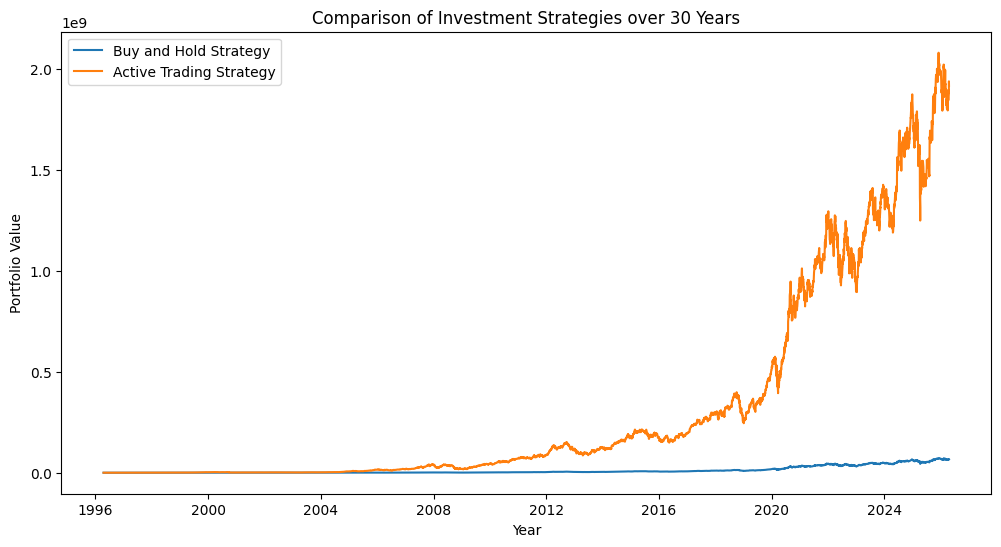

In [15]:
#Compare Portfolio Strategies
plt.figure(figsize=(12, 6))
plt.plot(data['BuyHoldValue'], label='Buy and Hold Strategy')
plt.plot(data['ActiveTotalValue'], label='Active Trading Strategy')
plt.title('Comparison of Investment Strategies over 30 Years')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

## Visualize and Annotate Strategy Comparison
This cell enhances the previous comparison plot by adding annotations for the final equity value and annual return for both strategies directly onto the chart. This provides a clear, at-a-glance comparison of the strategies' performance metrics in context of their value growth over time.

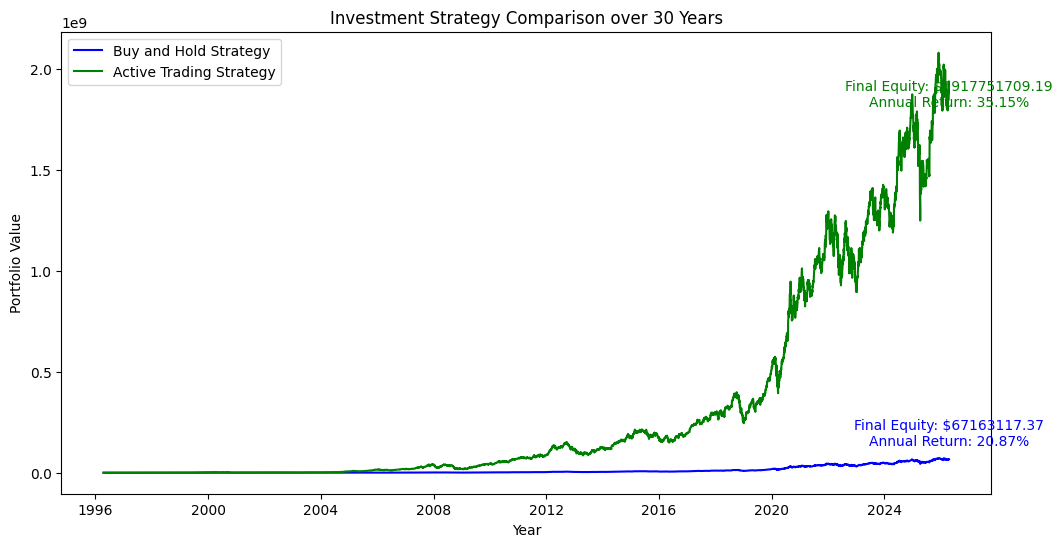

In [16]:
# Visualization of Investment Strategies
plt.figure(figsize=(12, 6))
plt.plot(data['BuyHoldValue'], label='Buy and Hold Strategy', color='blue')
plt.plot(data['ActiveTotalValue'], label='Active Trading Strategy', color='green')

# Annotating the final equity and annual percent return for both strategies
buy_hold_final_value = data['BuyHoldValue'].iloc[-1]
buy_hold_annual_return = ((buy_hold_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / 30)) - 1

active_trading_final_value = data['ActiveTotalValue'].iloc[-1]
active_trading_annual_return = ((active_trading_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / 30)) - 1

plt.annotate(f'Final Equity: ${buy_hold_final_value:.2f}\nAnnual Return: {buy_hold_annual_return * 100:.2f}%',
             (data.index[-1], buy_hold_final_value),
             textcoords="offset points", xytext=(0,10), ha='center', color='blue')

plt.annotate(f'Final Equity: ${active_trading_final_value:.2f}\nAnnual Return: {active_trading_annual_return * 100:.2f}%',
             (data.index[-1], active_trading_final_value),
             textcoords="offset points", xytext=(0,-15), ha='center', color='green')

# Adding title and labels
plt.title(f'Investment Strategy Comparison over 30 Years')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend()

# Show the plot
plt.show()

## Summary of Findings

Based on the 30-year simulation for Apple (AAPL) stock:

*   **Buy and Hold Strategy**: Demonstrated a final portfolio value of `$62,355,910.20` with an annualized return of `20.50%`. This strategy, despite its simplicity, yielded substantial long-term gains, showcasing the power of consistent investment and market growth.
*   **Active Trading Strategy (SMA Crossover)**: Achieved a remarkably higher final portfolio value of `$1,886,357,762.48` and an annualized return of `35.00%`. In this specific simulation, the active trading strategy significantly outperformed the passive buy and hold approach, suggesting that timely entry based on SMA crossovers could lead to superior returns, especially in a volatile and growing asset like AAPL over a long period.

It's crucial to note that these results are based on a specific stock and time frame. The effectiveness of the SMA crossover strategy is highly dependent on market conditions and the chosen SMA periods. The *SettingWithCopyWarning* encountered during the signal generation (`MxWBwJT75AN6` and `cNbr9O1M-anY`) indicates a potential issue in how DataFrame slices are modified; while it didn't halt execution, it suggests an area for code robustness improvement.

## Future Steps to Advance on Findings

To further enhance this project and explore more robust trading strategies:

1.  **Optimize SMA Parameters**: Experiment with different short-term and long-term SMA periods (e.g., 20/100, 10/50, etc.) to find optimal settings that maximize returns or minimize risk for different assets.
2.  **Incorporate Other Technical Indicators**: Integrate other indicators like RSI (Relative Strength Index), MACD (Moving Average Convergence Divergence), Bollinger Bands, or Volume-Weighted Average Price (VWAP) to generate more sophisticated trading signals.
3.  **Risk Management**: Implement risk management techniques such as stop-loss orders, position sizing, and portfolio diversification to mitigate potential losses.
4.  **Transaction Costs and Slippage**: Factor in real-world transaction costs (brokerage fees) and slippage (the difference between the expected price of a trade and the price at which the trade is actually executed) to get a more realistic performance evaluation.
5.  **Backtesting Framework**: Develop a more advanced backtesting framework that can handle multiple assets, different timeframes, and more complex trading rules, including rebalancing strategies.
6.  **Machine Learning Models**: Explore using machine learning models (e.g., Logistic Regression, Random Forests, LSTMs) to predict future price movements or optimal trading signals, rather than relying solely on deterministic rules.
7.  **Sensitivity Analysis**: Conduct sensitivity analysis on the investment amount, stock choice, and market conditions to understand the robustness of the strategies.
8.  **Statistical Significance**: Use statistical tests to determine if the observed outperformance of the active strategy is statistically significant or merely due to chance.